<a href="https://colab.research.google.com/github/E-Sentinel-Project/E-Sentinel/blob/master/fall_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from google.colab import files

# ------------------------------
# Upload file
# ------------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# ------------------------------
# Clean formatting first
# ------------------------------
df['Actual Fall'] = df['Actual Fall'].astype(str).str.strip().str.upper()

# Keep only TRUE/FALSE
df_clean = df[df['Actual Fall'].isin(['TRUE', 'FALSE'])].copy()

print("Total records after removing UNKNOWN:", len(df_clean))

# Convert to numeric
df_clean['actual'] = df_clean['Actual Fall'].map({'TRUE': 1, 'FALSE': 0})
df_clean['pred'] = df_clean['Predicted Fall'].astype(bool).astype(int)

y_true = df_clean['actual']
y_pred = df_clean['pred']

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

# ------------------------------
# Metrics
# ------------------------------
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
false_alert_rate = FP / (TP + FP) if (TP + FP) > 0 else 0

# ------------------------------
# Print Results
# ------------------------------
print("\n📌 METRICS FOR FALL-SUSPECTED EVENTS")
print("--------------------------------------")
print(f"True Fall Confirmation Rate (Recall): {recall * 100:.2f}%")
print(f"Precision (PPV):                      {precision * 100:.2f}%")
print(f"F1 Score:                             {f1 * 100:.2f}%")
print(f"False Alert Rate:                     {false_alert_rate * 100:.2f}%")

print("\n📌 Confusion Matrix (TN, FP, FN, TP):")
print(cm)

Saving fall_testing.csv to fall_testing (1).csv
Total records after removing UNKNOWN: 100

📌 METRICS FOR FALL-SUSPECTED EVENTS
--------------------------------------
True Fall Confirmation Rate (Recall): 93.88%
Precision (PPV):                      77.97%
F1 Score:                             85.19%
False Alert Rate:                     22.03%

📌 Confusion Matrix (TN, FP, FN, TP):
[[38 13]
 [ 3 46]]


Saving fall_testing.csv to fall_testing (3).csv
Final validation dataset size: 100


<Figure size 640x480 with 0 Axes>

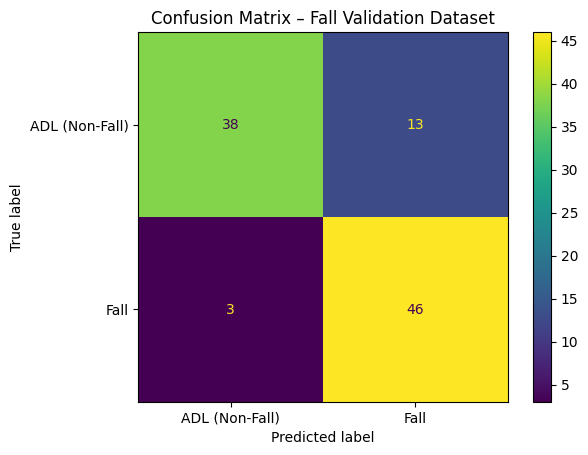

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

# Upload CSV file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# ------------------------------
# Clean formatting FIRST
# ------------------------------
df['Actual Fall'] = df['Actual Fall'].astype(str).str.strip().str.upper()

# Keep only TRUE/FALSE
df_clean = df[df['Actual Fall'].isin(['TRUE', 'FALSE'])].copy()

print("Final validation dataset size:", len(df_clean))

# Convert to numeric
df_clean['actual'] = df_clean['Actual Fall'].map({'TRUE': 1, 'FALSE': 0})
df_clean['pred'] = df_clean['Predicted Fall'].astype(bool).astype(int)

y_true = df_clean['actual']
y_pred = df_clean['pred']

# Force 2x2 confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ADL (Non-Fall)", "Fall"]
)

plt.figure()
disp.plot()
plt.title("Confusion Matrix – Fall Validation Dataset")
plt.show()